# Solving a RANK Model

This notebook solves a representative-agent New Keynesian (RANK) model with a global fixed-point algorithm. It is organized into four parts:

1. **Model:** household behavior, firm pricing, monetary and fiscal policy, market clearing, and equilibrium;
2. **Julia implementation:** calibration, state grids, and reusable numerical routines;
3. **Solution blocks:** the NKPC, representative-household Euler equation, market clearing, and aggregate forecasting tables;
4. **RANK fixed point:** the outer iteration, convergence diagnostics, and simulation.

The main equations and algorithmic steps remain visible in the notebook; reusable functions are collected in `src/`.


## 1. Julia setup

The notebook activates the repository's pinned Julia environment and loads the model functions from `src/`. It is self-contained when run from either the repository root or the `notebooks/` directory.


In [16]:
using Pkg

function find_project_root(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not find Project.toml from $(start_dir)")
        dir = parent
    end
end

project_root = find_project_root()
Pkg.activate(project_root)

using LinearAlgebra
using Statistics
using Random
using Printf
using Plots
using HANK

default(
    size=(760, 430),
    linewidth=2,
    framestyle=:box,
    legend=:best,
    gridalpha=0.25,
)

println("Julia version: ", VERSION)
println("Julia threads: ", Threads.nthreads())
println("Project: ", project_root)


  Activating

Julia version: 

 project at `c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\HANK`


1.12.5
Julia threads: 16
Project: c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\HANK


## 2. Model

### 2.1 Fundamentals and shocks

A representative-agent New Keynesian model combines two blocks:

- **Representative household:** chooses consumption, hours, and one-period government bonds.
- **New Keynesian firms:** monopolistically competitive firms produce with labor and set prices subject to Rotemberg adjustment costs.

There is no physical capital. A competitive final-good producer aggregates differentiated intermediate goods, the central bank follows a Taylor rule, and the fiscal authority keeps real government debt fixed.

The main aggregate variables are:

| Symbol | Meaning |
|---|---|
| $z_t$ | aggregate labor productivity |
| $\eta_t$ | monetary-policy shock |
| $c_t,n_t,b_{t+1}$ | consumption, hours, and bond holdings |
| $w_t,Y_t$ | real wage and output |
| $\Pi_t,i_t,R_t$ | gross inflation, nominal rate, and realized real return |
| $d_t,T_t$ | dividends and lump-sum transfers |

The aggregate exogenous state is

$$
s_t=(z_t,\eta_t).
$$

TFP and the monetary-policy shock follow independent AR(1) processes:

$$
\begin{aligned}
\log z_{t+1}&=\rho_z\log z_t+\varepsilon^z_{t+1},\\
\eta_{t+1}&=\rho_\eta\eta_t+\varepsilon^\eta_{t+1}.
\end{aligned}
$$

Tauchen discretization gives finite-state transition matrices $P_z$ and $P_\eta$. Independence implies

$$
P_s=P_z\otimes P_\eta.
$$


### 2.2 Household problem

The representative household has preferences

$$
E_0\sum_{t=0}^{\infty}\beta^t
\left(\log c_t-\frac{n_t^2}{2}\right).
$$

#### Budget constraint

Let $b_t$ denote real government-bond wealth carried into period $t$. The original budget constraint is

$$
c_t+b_{t+1}
=R_tb_t+w_tn_t+d_t+T_t,
\qquad b_{t+1}\geq0,
$$

where the realized gross real return is

$$
R_t=\frac{1+i_{t-1}}{\Pi_t}.
$$

The fiscal authority keeps real debt fixed at $B$ and rebates its net financing need through

$$
T_t=B-R_tB.
$$

Define shifted assets $\tilde a_t=b_t-B$. The household budget becomes

$$
c_t+\tilde a_{t+1}
=R_t\tilde a_t+w_tn_t+d_t,
\qquad \tilde a_{t+1}\geq-B.
$$

#### Bellman equation

Define nonlabor cash on hand as

$$
m_t\equiv R_t\tilde a_t+d_t.
$$

Let the aggregate shock be $s=(z,\eta)$. In a recursive equilibrium, aggregate variables are Markov functions

$$
X(s)=\bigl(w(s),Y(s)\bigr),
\qquad
\Pi(s)\equiv\Pi\bigl(s,X(s)\bigr).
$$

Current inflation and the Taylor rule determine the nominal return

$$
1+i(s)
=\bar R\Pi(s)^{\varphi_\pi}\exp(\eta).
$$

Conditional on next-period shock $s'$, the future real return is

$$
R(s';s)
=\frac{1+i(s)}{\Pi(s')}.
$$

The household's recursive problem is therefore

$$
\begin{aligned}
V(m,s)
=\max_{c,n,\tilde a'}\quad &
\log c-\frac{n^2}{2}
+\beta\sum_{s'}P(s'\mid s)
V(m',s')\\
\text{s.t.}\quad &
c+\tilde a'=m+w(s)n,\\
&\tilde a'\geq-B,\qquad c>0,\\
&m'=R(s';s)\tilde a'+d(s').
\end{aligned}
$$

The solution gives the complete household policy functions

$$
c=h_c(m,s),
\qquad n=h_n(m,s),
\qquad \tilde a'=h_a(m,s).
$$

The Bellman equation makes the timing explicit: the household knows the current nominal rate but integrates over next-period shocks, real returns, and dividends.

#### Optimality conditions

The intratemporal labor condition is

$$
n=\frac{w(s)}{c}.
$$

The Kuhn--Tucker condition for bond saving is

$$
\frac{1}{c}
\geq
\beta\sum_{s'}P(s'\mid s)
R(s';s)\frac{1}{c'},
$$

with equality whenever $\tilde a'>-B$.

#### Bond-market clearing

The representative household holds the entire fixed government debt supply:

$$
b_t=B
\quad\Longleftrightarrow\quad
\tilde a_t=0
$$

at every date. Hence $m(s)=d(s)$. Since $B>0$, the borrowing constraint is slack in equilibrium, so the Euler equation holds with equality. The equilibrium household budget simplifies to

$$
c_t=w_tn_t+d_t.
$$


### 2.3 Firm problem

#### Final-good demand

A competitive final-good producer combines a continuum of differentiated intermediate goods with a CES technology:

$$
Y_t
=\left[
\int_0^1 y_{j,t}^{\frac{\epsilon-1}{\epsilon}}dj
\right]^{\frac{\epsilon}{\epsilon-1}},
\qquad \epsilon>1.
$$

It chooses intermediate inputs to minimize expenditure:

$$
\min_{\{y_{j,t}\}_{j\in[0,1]}}
\int_0^1 p_{j,t}y_{j,t}dj
$$

subject to the CES production constraint. The resulting aggregate price index and demand for variety $j$ are

$$
P_t
=\left[
\int_0^1 p_{j,t}^{1-\epsilon}dj
\right]^{\frac{1}{1-\epsilon}},
\qquad
y_{j,t}
=\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}Y_t.
$$

#### Intermediate firms and current profits

Intermediate firm $j$ produces with labor only:

$$
y_{j,t}=z_t\ell_{j,t},
\qquad
\ell_{j,t}
=\frac{1}{z_t}
\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}Y_t.
$$

The firm inherits last period's price $p_{j,t-1}$ and pays a Rotemberg cost when changing it. Measured in units of the final good, current profits are

$$
\mathcal D_{j,t}
=\left[
\left(\frac{p_{j,t}}{P_t}\right)^{1-\epsilon}
-\frac{w_t}{z_t}
\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}
-\frac{\kappa}{2}
\left(\frac{p_{j,t}}{p_{j,t-1}}-1\right)^2
\right]Y_t.
$$

A larger $\kappa$ makes prices more rigid; $\kappa=0$ gives flexible prices.

#### Dynamic price setting

Let $p_{-1}$ be the firm's inherited price, $s$ the aggregate shock, $X=(w,Y)$ the current aggregate variables, and $P$ the aggregate price level. Taking aggregate variables and the equilibrium functions as given, the firm's value function is

$$
J(p_{-1},s,X,P)
=\max_p\left\{
\mathcal D(p,p_{-1};s,X,P)
+\beta_F\sum_{s'}\Pr(s'\mid s)
J\!\left(p,s',X',P'\right)
\right\},
$$

where

$$
X'=X(s'),
\qquad
P'=\Pi(s',X')P.
$$

The firm chooses its current price $p$. This price becomes next period's inherited price, while future aggregate variables are read from the equilibrium functions. Future profits are discounted by the constant factor $\beta_F$.

#### Symmetric equilibrium and the nonlinear NKPC

The individual firm first chooses $p_{j,t}$ while treating the aggregate price index $P_t$ as given. Symmetry is imposed only after deriving the firm's first-order condition:

$$
p_{j,t}=P_t,
\qquad
y_{j,t}=Y_t,
\qquad
\Pi_t
=\frac{P_t}{P_{t-1}}
=\frac{p_{j,t}}{p_{j,t-1}},
\qquad
Y_t=z_tN_t.
$$

The resulting nonlinear New Keynesian Phillips curve is

$$
(1-\epsilon)+\epsilon\frac{w_t}{z_t}
-\kappa(\Pi_t-1)\Pi_t
+\beta_F E_t\!\left[
\frac{Y_{t+1}}{Y_t}
\kappa(\Pi_{t+1}-1)\Pi_{t+1}
\right]=0.
$$

Under flexible prices, this reduces to

$$
\frac{w_t}{z_t}=\frac{\epsilon-1}{\epsilon},
$$

so real marginal cost equals the inverse desired markup. Given the equilibrium functions for future wages and output, the nonlinear NKPC determines the inflation policy $\Pi(s,X)=\Pi(z,\eta,w,Y)$.

#### Dividends and resource costs

In symmetric equilibrium, real revenue is $Y_t$, the wage bill is $(w_t/z_t)Y_t$, and Rotemberg adjustment costs absorb final goods. Dividends paid to the representative household are therefore

$$
d_t
=\left[
1-\frac{w_t}{z_t}
-\frac{\kappa}{2}(\Pi_t-1)^2
\right]Y_t.
$$

Thus price adjustment costs affect both firm pricing and the resources distributed to the household.


### 2.4 Monetary and fiscal policy

The central bank follows

$$
1+i_t=\bar R\Pi_t^{\varphi_\pi}\exp(\eta_t).
$$

The next realized real return is

$$
R_{t+1}
=\frac{1+i_t}{\Pi_{t+1}}
=\bar R
\frac{\Pi_t^{\varphi_\pi}\exp(\eta_t)}{\Pi_{t+1}}.
$$

The fiscal authority fixes $B_t=B$ and sets $T_t=B-R_tB$. In RANK, $B$ affects the off-equilibrium borrowing limit but not the equilibrium allocation: interest receipts on $B$ are exactly offset by the fiscal transfer rule.


### 2.5 Market clearing and feasibility

Given the aggregate state $s_t$, the two unknown aggregates $(w_t,Y_t)$ satisfy

$$
\tilde a_{t+1}=0
\qquad\text{(bond market)},
$$

$$
n_t=\frac{Y_t}{z_t}
\qquad\text{(labor market)}.
$$

The first condition is equivalent to household bond holdings of $b_{t+1}=B$; the second equates household labor supply with firms' labor demand. Real-resource-cost dividends imply the goods-market feasibility condition

$$
c_t+\frac{\kappa}{2}(\Pi_t-1)^2Y_t=Y_t.
$$

This resource constraint is not a third independent market-clearing equation. It holds automatically by Walras' law.


### 2.6 Recursive equilibrium

Let

$$
s=(z,\eta),
\qquad
X(s)=\bigl(w(s),Y(s)\bigr).
$$

For the firm pricing policy, $X=(w,Y)$ denotes a generic current aggregate point.

A recursive RANK equilibrium is a collection

$$
\left\{
V(m,s),h_c(m,s),h_n(m,s),h_a(m,s);
\ \Pi(s,X),\Pi(s),d(s),i(s),R(s';s),T(s';s);
\ w(s),Y(s)
\right\}.
$$

which satisfy:

1. **Household optimality:** Given $X(s)$, $R(s';s)$, and $d(s)$, $V$ solves the household Bellman equation and $(h_c,h_n,h_a)$ are optimal.

$$
\begin{aligned}
V(m,s)
=\max_{c,n,\tilde a'}\quad &
\log c-\frac{n^2}{2}
+\beta\sum_{s'}P(s'\mid s)
V(m',s')\\
\text{s.t.}\quad &
c+\tilde a'=m+w(s)n,\\
&\tilde a'\geq-B,\qquad c>0,\\
&m'=R(s';s)\tilde a'+d(s').
\end{aligned}
$$

2. **Firm optimality:** Given the future equilibrium function $X(s')$, $\Pi(s,X)$ solves the nonlinear NKPC:

$$
\begin{aligned}
0={}&(1-\epsilon)+\epsilon\frac{w}{z}
-\kappa\bigl(\Pi(s,X)-1\bigr)\Pi(s,X)\\
&+\beta_F\sum_{s'}P(s'\mid s)
\frac{Y(s')}{Y}
\kappa\left[\Pi\bigl(s',X(s')\bigr)-1\right]
\Pi\bigl(s',X(s')\bigr).
\end{aligned}
$$


3. **Policy consistency:** The equilibrium policies satisfy the pricing, dividend, Taylor-rule, Fisher, and fixed-debt fiscal equations:

$$
\begin{aligned}
\Pi(s)&=\Pi\bigl(s,X(s)\bigr),\\
d(s)
&=\left[1-\frac{w(s)}{z}
-\frac{\kappa}{2}\bigl(\Pi(s)-1\bigr)^2\right]Y(s),\\
1+i(s)
&=\bar R\Pi(s)^{\varphi_\pi}\exp(\eta),\\
R(s';s)
&=\frac{1+i(s)}{\Pi(s')},\\
T(s';s)
&=B-R(s';s)B.
\end{aligned}
$$

4. **Aggregate consistency and market clearing:** $w(s)$ and $Y(s)$ satisfy the bond- and labor-market equations:

$$
h_a\bigl(d(s),s\bigr)=0,
\qquad
h_n\bigl(d(s),s\bigr)=\frac{Y(s)}{z}.
$$




### 2.7 Numerical algorithm: inner and outer loops

The global solution represents equilibrium wages and output by two tables over the aggregate Markov state:

$$
\widehat X(s)=\bigl(\widehat w(s),\widehat Y(s)\bigr),
\qquad s=(z,\eta).
$$

#### Inner equilibrium: given $\widehat X$

1. Solve the forward-looking nonlinear NKPC and obtain $\Pi(s,X)$ and $d(s,X)$.
2. Impose bond-market clearing, $\tilde a=\tilde a'=0$. Given $\widehat X$, use the household budget constraint and labor FOC to recover current and future consumption, and construct the Euler residual $F_E(w,Y;s)$.
3. For every state $s$, find $(w,Y)$ such that the Euler equation and labor-market clearing condition hold:

   $$
   F_E(w,Y;s)=0,
   \qquad
   h_n\bigl(d(s,X),s,X\bigr)=\frac{Y}{z}.
   $$

   Denote the solution by

   $$
   X^{\mathrm{clear}}(s)
   =\bigl(w^{\mathrm{clear}}(s),Y^{\mathrm{clear}}(s)\bigr).
   $$

#### Outer loop: update the forecast tables

Update in logs using damping parameter $\lambda$:

$$
\log\widehat X^{\mathrm{new}}(s)
=(1-\lambda)\log\widehat X^{\mathrm{old}}(s)
+\lambda\log X^{\mathrm{clear}}(s).
$$

The NKPC is warm-started from the preceding outer iteration. Early iterations use only a few pricing updates; the update budget rises as the forecast distance falls. A strict pricing--table polishing loop is applied before the household policies are recovered.


## 3. Calibration and state grids

The following calibration is used throughout the notebook.

| Parameter | Value | Economic meaning |
|---|---:|---|
| $\beta$ | 0.975 | household discount factor |
| $\beta_F$ | 0.975 | firm discount factor |
| $\epsilon$ | 10 | elasticity across intermediate varieties |
| $\kappa$ | 100 | Rotemberg price-adjustment cost |
| $\varphi_\pi$ | 1.5 | Taylor-rule response to inflation |
| $\bar R$ | $0.997/0.975$ | Taylor-rule intercept |
| $B$ | 5 | fixed real government debt |
| $(\rho_z,\sigma_z)$ | $(0.9,0.07\sqrt{1-0.9^2})$ | TFP process |
| $(\rho_\eta,\sigma_\eta)$ | $(0.9,0.002\sqrt{1-0.9^2})$ | monetary-policy shock process |
| $m_\tau$ | 2.9 | Tauchen grid width |

The numerical configuration uses 11 TFP states, 11 monetary-policy states, 7 wage nodes, and 31 output nodes.


In [17]:
par = RANKParams()
model = RANKModel(par)

println("Deterministic steady state")
println(repeat("-", 48))
@printf("%-28s %12.8f\n", "gross inflation", model.steady_inflation)
@printf("%-28s %12.8f\n", "gross real return", model.steady_real_return)
@printf("%-28s %12.8f\n", "real wage", model.steady_wage)
@printf("%-28s %12.8f\n", "output", model.steady_output)
@printf("%-28s %12.8f\n", "consumption", model.steady_consumption)

println("\nGrid sizes")
println(repeat("-", 48))
println("aggregate shock nodes  = ", (par.n_z, par.n_eta))
println("wage/output nodes      = ", (par.n_wages, par.n_outputs))
println("wage grid              = ", extrema(model.wage_grid))
println("output grid            = ", extrema(model.output_grid))


Deterministic steady state
------------------------------------------------
gross inflation                1.00602711
gross real return              1.02564103
real wage                      0.90151586
output                         0.95034534
consumption                    0.94861922

Grid sizes
------------------------------------------------
aggregate shock nodes  = (11, 11)
wage/output nodes      = (7, 31)
wage grid              = (0.55, 1.25)
output grid            = (0.6, 1.4)


### 3.1 Deterministic steady state

In a deterministic steady state, the household Euler equation requires

$$
R^*=\frac{1}{\beta}.
$$

The Taylor rule implies

$$
R^*=\bar R(\Pi^*)^{\varphi_\pi-1}.
$$

Combining the two equations gives

$$
\Pi^*
=\left(\frac{1}{\beta\bar R}\right)^{1/(\varphi_\pi-1)}.
$$

Under the calibration above, $\Pi^*\approx1.006$. The steady wage follows from the nonlinear NKPC, while steady consumption, hours, and output follow from the labor FOC, production, and the resource constraint.


## 4. Step 0: initialize perceived equilibrium tables

The initial guess uses the flexible-price/log-utility benchmark:

$$
\widehat w^{(0)}(z,\eta)=w^*z,
\qquad
\widehat Y^{(0)}(z,\eta)=Y^*z.
$$

The guess ignores the small monetary shock initially but already captures the first-order TFP scaling. This keeps the first market-clearing pass inside the aggregate grids.


Initial forecast ranges
wage   = (0.7338697834719826, 1.1013936442065662)
output = (0.7736189234325769, 1.1610492549174372)


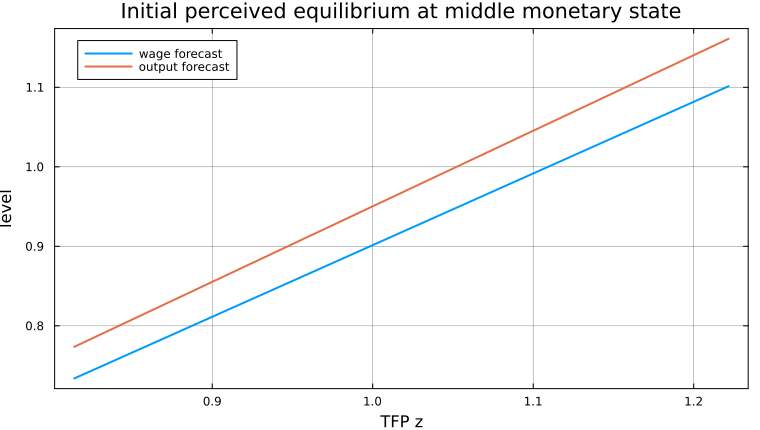

In [18]:
initial_rules = initial_rank_forecast_rules(model)

println("Initial forecast ranges")
println("wage   = ", extrema(initial_rules.wage))
println("output = ", extrema(initial_rules.output))

eta_middle = div(par.n_eta, 2) + 1
initial_rule_plot = plot(
    model.z_grid,
    initial_rules.wage[:, eta_middle];
    label="wage forecast",
    xlabel="TFP z",
    ylabel="level",
    title="Initial perceived equilibrium at middle monetary state",
)
plot!(
    initial_rule_plot,
    model.z_grid,
    initial_rules.output[:, eta_middle];
    label="output forecast",
)
initial_rule_plot


## 5. Step 1: solve the nonlinear NKPC

Define

$$
x(s,w,Y)=\kappa\bigl(\Pi(s,w,Y)-1\bigr)\Pi(s,w,Y).
$$

Given the forecast tables, the nonlinear NKPC can be written as

$$
\begin{aligned}
x(s,w,Y)
={}&(1-\epsilon)+\epsilon\frac{w}{z}\\
&+\beta_F\sum_{s'}P(s'|s)
\frac{\widehat Y(s')}{Y}
x\bigl(s',\widehat w(s'),\widehat Y(s')\bigr).
\end{aligned}
$$

Starting from $x^{(0)}(s,w,Y)$, one fixed-point update is

$$
\begin{aligned}
x^{\mathrm{new}}(s,w,Y)
={}&(1-\epsilon)+\epsilon\frac{w}{z}\\
&+\beta_F\sum_{s'}P(s'|s)
\frac{\widehat Y(s')}{Y}
x^{(j)}\bigl(s',\widehat w(s'),\widehat Y(s')\bigr).
\end{aligned}
$$

The implementation applies damping,

$$
x^{(j+1)}=(1-\lambda_\Pi)x^{(j)}+\lambda_\Pi x^{\mathrm{new}},
$$

and iterates until $\lVert x^{(j+1)}-x^{(j)}\rVert_\infty$ is below tolerance. Gross inflation is then recovered from the positive root of $x=\kappa(\Pi^2-\Pi)$:

$$
\Pi=\frac{1+\sqrt{1+4x/\kappa}}{2}.
$$

For off-grid evaluation, multiply the NKPC by current output and define

$$
q(s,w,Y)=Yx(s,w,Y).
$$

Then

$$
q=Y\left[(1-\epsilon)+\epsilon\frac{w}{z}\right]
+\beta_F\sum_{s'}P(s'|s)q(s',\widehat X(s')),
$$

which is bilinear in current $(w,Y)$. The code therefore interpolates $q=Yx$, divides by $Y$ to recover $x$, and then recovers $\Pi$.


In [19]:
initial_nkpc = solve_rank_nkpc(
    model, par, initial_rules; max_steps=20,
)

println("NKPC iterations           = ", length(initial_nkpc.error_history))
println("NKPC update error          = ", last(initial_nkpc.error_history))
println("inflation policy range     = ", extrema(initial_nkpc.inflation_policy))
println("inflation array size       = ", size(initial_nkpc.inflation_policy))


NKPC iterations           = 20
NKPC update error          = 0.007760218007954123
inflation policy range     = (0.9534287949848759, 1.060768453929688)
inflation array size       = (11, 11, 7, 31)


## 6. Step 2: solve the reduced household equilibrium

At outer iteration $k$, Step 1 has solved the pricing block under the forecast table $\widehat X^k$.

**Input:** $\quad s,\widehat X^k(s'),\Pi^k(s,X)$

**Output:** $\quad F^k(w,Y;s)$

Bond-market clearing places the representative household on the equilibrium locus

$$
\tilde a=\tilde a'=0.
$$

Because $B>0$, the constraint $\tilde a'\geq-B$ is slack at this point, so the Euler equation holds with equality. For a trial $X=(w,Y)$, evaluate

$$
\Pi=\Pi^k(s,X),
\qquad
d(s,X)
=\left[1-\frac{w}{z}
-\frac{\kappa}{2}\bigl(\Pi^k(s,X)-1\bigr)^2\right]Y.
$$

Substituting $n=w/c$ into $c=wn+d(s,X)$ gives

$$
c^2-d(s,X)c-w^2=0.
$$

Taking the positive root gives

$$
\mathcal C^k(s,X)
=\frac{d(s,X)+\sqrt{d(s,X)^2+4w^2}}{2},
\qquad
\mathcal N^k(s,X)
=\frac{w}{\mathcal C^k(s,X)}.
$$

These are candidate equilibrium-locus choices conditional on the trial $X$; they are not yet the complete household policies.

For each future state $s'$, set $X'=\widehat X^k(s')$ and compute

$$
R'(s';s,X)
=\frac{1+i(s,X)}{\Pi^k(s',\widehat X^k(s'))}.
$$

The two residuals are

$$
F_E^k(w,Y;s)
=\frac{1}{\mathcal C^k(s,X)}
-\beta\sum_{s'}P(s'\mid s)
R'(s';s,X)
\frac{1}{\mathcal C^k(s',\widehat X^k(s'))},
$$

$$
F_N^k(w,Y;s)
=\mathcal N^k(s,X)-\frac{Y}{z}.
$$

Thus Step 2 constructs

$$
F^k(w,Y;s)
=\begin{bmatrix}F_E^k(w,Y;s)\\F_N^k(w,Y;s)\end{bmatrix}.
$$

In [20]:
z_middle = argmin(abs.(model.log_z_grid))
eta_middle = argmin(abs.(model.log_eta_grid))

household_probe = rank_household_residuals(
    initial_rules.wage[z_middle, eta_middle],
    initial_rules.output[z_middle, eta_middle],
    initial_nkpc.inflation_policy,
    initial_rules,
    model,
    z_middle,
    eta_middle,
    par,
)

println("Household block at the initial middle-state forecast")
println(repeat("-", 58))
@printf("%-34s %16.6e\n", "Euler residual", household_probe.euler)
@printf("%-34s %16.6e\n", "labor residual", household_probe.labor)
@printf("%-34s %16.8f\n", "consumption", household_probe.consumption)
@printf("%-34s %16.8f\n", "hours", household_probe.hours)


Household block at the initial middle-state forecast
----------------------------------------------------------
Euler residual                         2.159470e-03
labor residual                        -8.902108e-04
consumption                              0.94690485
hours                                    0.94945513


## 7. Step 3: solve for $X^{\mathrm{clear}}$

For every state $s$, use $\widehat X^k(s)$ as the initial guess and solve

$$
F_E^k(w,Y;s)=0,
\qquad
F_N^k(w,Y;s)=0.
$$

The implementation uses a damped two-dimensional Newton method with a finite-difference Jacobian. Its output is

$$
X^{\mathrm{clear},k}(s)
=\left(w^{\mathrm{clear},k}(s),Y^{\mathrm{clear},k}(s)\right).
$$

Repeating the root solve at every $(z,\eta)$ node produces the complete table $X^{\mathrm{clear},k}$ passed to the outer update.

In [21]:
first_equilibrium_map = solve_rank_household_grid(
    initial_nkpc.inflation_policy,
    initial_rules,
    model,
    par;
    tolerance=1e-9,
)
first_fitted_rules = RANKForecastRules(
    first_equilibrium_map.wage,
    first_equilibrium_map.output,
)

println("First market-clearing pass")
println(repeat("-", 52))
@printf("%-31s %16.3e\n", "maximum Euler residual",
    maximum(abs.(first_equilibrium_map.euler_residual)))
@printf("%-31s %16.3e\n", "maximum labor residual",
    maximum(abs.(first_equilibrium_map.labor_residual)))
@printf("%-31s %16.3e\n", "forecast-table distance",
    rank_forecast_distance(initial_rules, first_fitted_rules))
println("all statewise Newton solves converged = ", all(first_equilibrium_map.converged))


First market-clearing pass
----------------------------------------------------
maximum Euler residual                 9.145e-10
maximum labor residual                 2.518e-10
forecast-table distance                5.181e-02
all statewise Newton solves converged = true


## 8. Step 4: update the aggregate tables

Update the perceived equilibrium table in logs:

$$
\log\widehat X^{k+1}(s)
=(1-\lambda)\log\widehat X^k(s)
+\lambda\log X^{\mathrm{clear},k}(s).
$$

The aggregate loop is

```text
forecast tables
    -> iterate the NKPC fixed point
    -> construct the Euler and labor residuals
    -> solve for Xclear at every shock node
    -> damp the wage/output tables
    -> repeat
```

The NKPC update is warm-started. Its step budget rises from 20 to 40, 80, 160, and 320 as the aggregate-table distance falls. Once the coarse fixed point is reached, a strict NKPC polishing loop makes the pricing and aggregate tables mutually consistent.

## 9. Step 5: recover the complete household policies

After the aggregate fixed point has converged, hold $X(s)$ and $\Pi(s)$ fixed and solve the household problem on $(m,s)$ with EGM. Only the consumption policy is iterated.

Given $h_c^j(m,s)$ and an exogenous choice $\tilde a'$, compute

$$
m'(s')=R(s';s)\tilde a'+d(s'),
$$

$$
c
=\left[
\beta\sum_{s'}P(s'\mid s)
\frac{R(s';s)}{h_c^j(m'(s'),s')}
\right]^{-1},
\qquad
n=\frac{w(s)}{c}.
$$

The corresponding endogenous cash node is

$$
m^{\mathrm{endo}}=c+\tilde a'-w(s)n.
$$

Interpolating from $m^{\mathrm{endo}}$ to the fixed cash grid gives

$$
h_a^{j+1}(m,s),
\qquad
h_c^{j+1}(m,s),
\qquad
h_n^{j+1}(m,s).
$$

Below the first endogenous node, the borrowing constraint binds and $h_a(m,s)=-B$. Iterate until the consumption-policy distance converges. Finally evaluate the policies at the equilibrium cash point $m=d(s)$ and verify

$$
h_a(d(s),s)=0,
\qquad
h_n(d(s),s)=\frac{Y(s)}{z}.
$$

In [22]:
solve_start = time()
result = solve_rank(
    par;
    initial_rules=initial_rules,
    max_outer_iterations=300,
    outer_tolerance=1e-5,
    forecast_damping=0.20,
    nkpc_steps_per_outer=20,
    nkpc_max_steps_per_outer=320,
    polish_tolerance=1e-7,
    market_tolerance=1e-9,
    policy_tolerance=1e-8,
    verbose=true,
)
solve_seconds = time() - solve_start
summary_stats = rank_solution_summary(result)

println("RANK solution summary")
println(repeat("-", 58))
println(rpad("converged", 34), summary_stats.converged)
println(rpad("aggregate outer iterations", 34), summary_stats.outer_iterations)
println(rpad("strict polishing iterations", 34), summary_stats.polish_iterations)
println(rpad("household EGM iterations", 34), summary_stats.household_iterations)
@printf("%-34s %.3e\n", "forecast-table distance", summary_stats.rule_distance)
@printf("%-34s %.3e\n", "NKPC iteration error", summary_stats.nkpc_iteration_error)
@printf("%-34s %.3e\n", "household policy error", summary_stats.egm_iteration_error)
@printf("%-34s %.3e\n", "maximum bond residual", summary_stats.max_bond_residual)
@printf("%-34s %.3e\n", "policy labor residual", summary_stats.max_policy_labor_residual)
@printf("%-34s %.3f seconds\n", "wall-clock solve time", solve_seconds)

 iter | NKPC error | rule distance | max clearing | clear share
----------------------------------------------------------------------
    1 |   7.76e-03 |      5.18e-02 |     9.14e-10 |      1.0000
    2 |   2.04e-02 |      4.77e-02 |     8.09e-10 |      1.0000
    3 |   2.65e-02 |      4.32e-02 |     9.05e-10 |      1.0000
    4 |   2.78e-02 |      3.88e-02 |     9.69e-10 |      1.0000
    5 |   2.66e-02 |      3.49e-02 |     9.85e-10 |      1.0000
    6 |   2.40e-02 |      3.49e-02 |     9.05e-10 |      1.0000
    7 |   2.08e-02 |      3.72e-02 |     9.00e-10 |      1.0000
    8 |   1.75e-02 |      3.88e-02 |     9.43e-10 |      1.0000
    9 |   1.43e-02 |      3.95e-02 |     9.85e-10 |      1.0000
   10 |   1.13e-02 |      3.94e-02 |     9.96e-10 |      1.0000
   11 |   8.73e-03 |      3.86e-02 |     8.81e-10 |      1.0000
   12 |   7.75e-03 |      3.73e-02 |     7.52e-10 |      1.0000
   13 |   7.27e-03 |      3.56e-02 |     7.24e-10 |      1.0000
   14 |   6.69e-03 |      3.38e-0

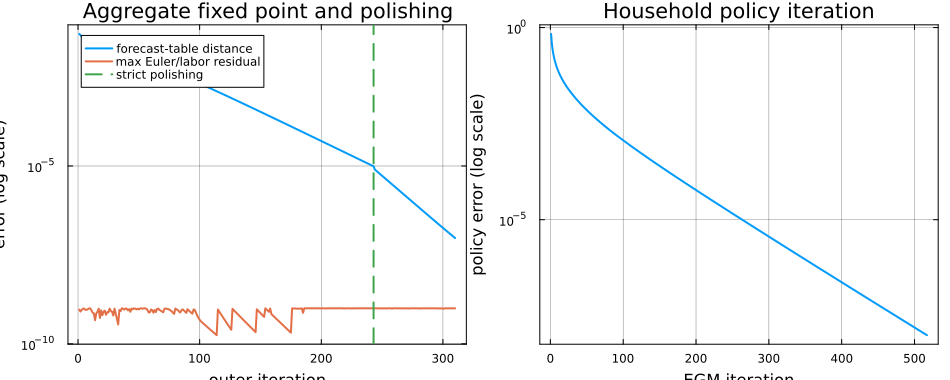

In [23]:
aggregate_iterations = collect(eachindex(result.history))
history_has_phase = !isempty(result.history) && hasproperty(first(result.history), :phase)
outer_count = history_has_phase ?
    count(entry -> entry.phase == :outer, result.history) : length(result.history)
rule_distance = [entry.rule_distance for entry in result.history]
clearing_error = [max(entry.max_clearing_error, eps()) for entry in result.history]

aggregate_convergence = plot(
    aggregate_iterations,
    rule_distance;
    yscale=:log10,
    label="forecast-table distance",
    xlabel="outer iteration",
    ylabel="error (log scale)",
    title="Aggregate fixed point and polishing",
)
plot!(
    aggregate_convergence,
    aggregate_iterations,
    clearing_error;
    label="max Euler/labor residual",
)
vline!(aggregate_convergence, [outer_count]; label="strict polishing", linestyle=:dash)

egm_error = result.household.error_history
household_convergence = plot(
    eachindex(egm_error),
    egm_error;
    yscale=:log10,
    label=false,
    xlabel="EGM iteration",
    ylabel="policy error (log scale)",
    title="Household policy iteration",
)

plot(aggregate_convergence, household_convergence; layout=(1, 2), size=(950, 380))

### 9.1 Household policy functions

The policies below are functions of cash on hand $m$. The vertical line marks the equilibrium point $m=d(s)$ in the middle aggregate state. The plot omits the far-right numerical boundary, where the finite asset grid forces savings to its upper endpoint.

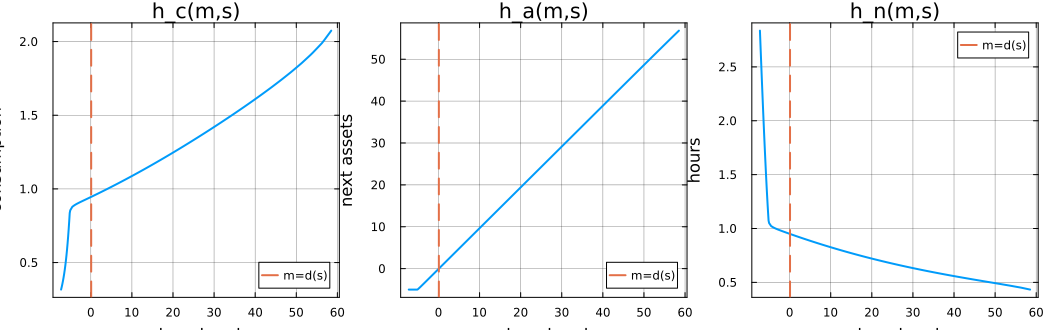

In [24]:
household = result.household
z_middle = argmin(abs.(model.log_z_grid))
eta_middle = argmin(abs.(model.log_eta_grid))
middle_state = z_middle + (eta_middle - 1) * par.n_z
equilibrium_cash = household.environment.dividend[middle_state]

# Do not plot the artificial upper-asset boundary.
saving_slice = household.saving[:, middle_state]
plot_asset_limit = 0.95 * last(model.asset_grid)
last_interior = findlast(value -> value <= plot_asset_limit, saving_slice)
plot_range = firstindex(household.cash_grid):last_interior
plot_cash = household.cash_grid[plot_range]

p_hc = plot(
    plot_cash,
    household.consumption[plot_range, middle_state];
    label=false,
    xlabel="cash on hand m",
    ylabel="consumption",
    title="h_c(m,s)",
)
vline!(p_hc, [equilibrium_cash]; label="m=d(s)", linestyle=:dash)

p_ha = plot(
    plot_cash,
    household.saving[plot_range, middle_state];
    label=false,
    xlabel="cash on hand m",
    ylabel="next assets",
    title="h_a(m,s)",
)
vline!(p_ha, [equilibrium_cash]; label="m=d(s)", linestyle=:dash)

p_hn = plot(
    plot_cash,
    household.hours[plot_range, middle_state];
    label=false,
    xlabel="cash on hand m",
    ylabel="hours",
    title="h_n(m,s)",
)
vline!(p_hn, [equilibrium_cash]; label="m=d(s)", linestyle=:dash)

household_policy_plot =
    plot(p_hc, p_ha, p_hn; layout=(1, 3), size=(1050, 330))

## 10. Solution checks

The final solution verifies the aggregate fixed point and the recovered household policies separately. In particular, the EGM policies must clear the bond and labor markets when evaluated at $m=d(s)$.

In [25]:
diagnostics = rank_equilibrium_diagnostics(result)

println("Equilibrium diagnostics")
println(repeat("-", 62))
@printf("%-36s %16.3e\n", "forecast-table distance", diagnostics.forecast_distance)
@printf("%-36s %16.3e\n", "maximum Euler residual", diagnostics.max_euler_residual)
@printf("%-36s %16.3e\n", "maximum NKPC residual", diagnostics.max_nkpc_residual)
@printf("%-36s %16.3e\n", "maximum EGM bond residual", diagnostics.max_bond_residual)
@printf("%-36s %16.3e\n", "EGM labor residual", diagnostics.max_policy_labor_residual)
@printf("%-36s %16.3e\n", "household policy error", diagnostics.household_policy_error)
@printf("%-36s %16.3e\n", "minimum endogenous-grid spacing", diagnostics.minimum_egm_spacing)
println(rpad("cash grid", 37), diagnostics.household_cash_bounds)
println(rpad("cash reached by transitions", 37), diagnostics.reached_cash_range)

@assert result.converged "RANK solution did not converge"
@assert diagnostics.all_markets_converged
@assert diagnostics.forecast_distance <= 1.1e-7
@assert diagnostics.max_euler_residual < 1e-7
@assert diagnostics.max_bond_residual < 2e-6
@assert diagnostics.max_policy_labor_residual < 2e-6
@assert diagnostics.household_policy_error <= 1.1e-8
@assert diagnostics.minimum_egm_spacing > 0.0
@assert diagnostics.max_nkpc_residual < 2e-6
@assert diagnostics.wage_boundary_share == 0.0
@assert diagnostics.output_boundary_share == 0.0

Equilibrium diagnostics
--------------------------------------------------------------
forecast-table distance                     9.418e-08
maximum Euler residual                      9.088e-09
maximum NKPC residual                       3.780e-07
maximum EGM bond residual                   6.742e-07
EGM labor residual                          3.181e-07
household policy error                      9.899e-09
minimum endogenous-grid spacing             1.583e-02
cash grid                            (-7.230772711904202, 70.54572192101112)
cash reached by transitions          (-5.735070892040446, 69.05002010114737)


### 10.1 Aggregate equilibrium functions

The following slices hold the monetary shock at its middle node and show how the solved allocation varies with TFP. Since the model is nonlinear, these are levels rather than local linear impulse responses.


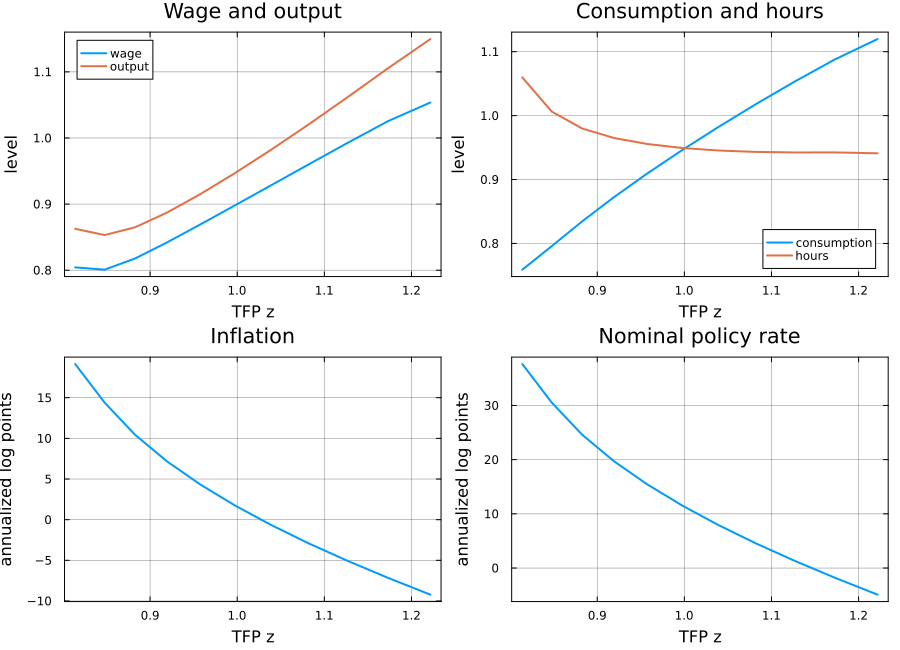

In [26]:
equilibrium = result.equilibrium
eta_middle = div(par.n_eta, 2) + 1

p_wy = plot(
    model.z_grid,
    equilibrium.wage[:, eta_middle];
    label="wage",
    xlabel="TFP z",
    ylabel="level",
    title="Wage and output",
)
plot!(p_wy, model.z_grid, equilibrium.output[:, eta_middle]; label="output")

p_cp = plot(
    model.z_grid,
    equilibrium.consumption[:, eta_middle];
    label="consumption",
    xlabel="TFP z",
    ylabel="level",
    title="Consumption and hours",
)
plot!(p_cp, model.z_grid, equilibrium.hours[:, eta_middle]; label="hours")

p_pi = plot(
    model.z_grid,
    400 .* log.(equilibrium.inflation[:, eta_middle]);
    label=false,
    xlabel="TFP z",
    ylabel="annualized log points",
    title="Inflation",
)

p_i = plot(
    model.z_grid,
    400 .* log.(1 .+ equilibrium.nominal_rate[:, eta_middle]);
    label=false,
    xlabel="TFP z",
    ylabel="annualized log points",
    title="Nominal policy rate",
)

plot(p_wy, p_cp, p_pi, p_i; layout=(2, 2), size=(900, 650))


## 11. Generalized impulse responses

For an aggregate variable $q$, compare a shocked initial state $s_0^\delta$ with the middle baseline state $s_0^0$:

$$
\operatorname{GIRF}_q(h)
=E\left[q(s_h)\mid s_0=s_0^\delta\right]
-E\left[q(s_h)\mid s_0=s_0^0\right].
$$

Here the aggregate state is an exogenous finite Markov chain. Hence the conditional expectations are computed exactly:

$$
\operatorname{GIRF}_q(h)
=\left(\mu_h^\delta-\mu_h^0\right)'q,
\qquad
\mu_{h+1}=P'\mu_h.
$$

No Monte Carlo simulation is needed for these responses.

In [27]:
tfp_girf = rank_generalized_irf(
    result;
    shock=:tfp,
    direction=1,
    horizon=40,
)
monetary_girf = rank_generalized_irf(
    result;
    shock=:monetary,
    direction=1,
    horizon=40,
)

@printf("TFP impact shock       = %+.3f innovation s.d.\n",
    tfp_girf.impact_innovation_sd)
@printf("Monetary impact shock  = %+.3f innovation s.d.\n",
    monetary_girf.impact_innovation_sd)

TFP impact shock       = +1.331 innovation s.d.
Monetary impact shock  = +1.331 innovation s.d.


### 11.1 Positive TFP shock

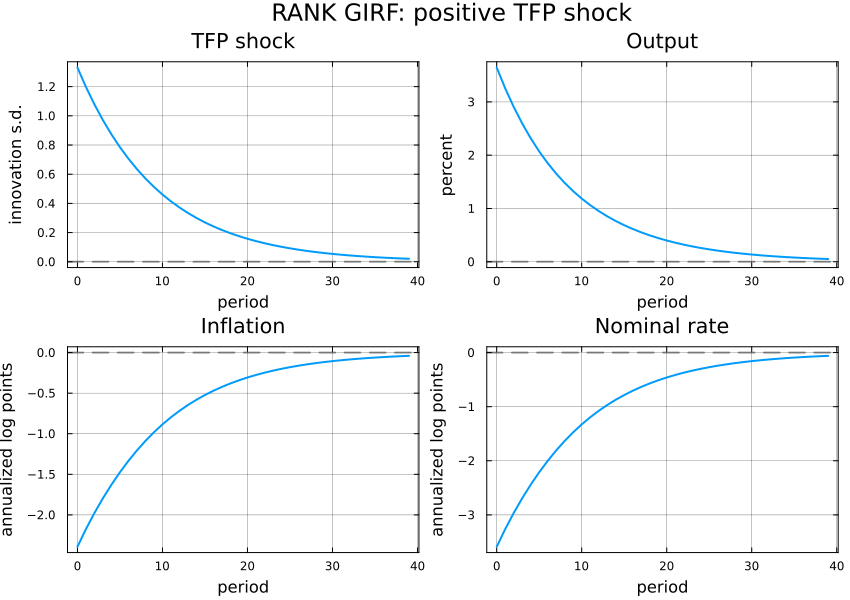

In [28]:
function plot_rank_girf(girf; figure_title)
    periods = 0:(girf.horizon - 1)
    shock_response = if girf.shock == :tfp
        girf.response.log_tfp ./ par.sigma_z
    else
        girf.response.log_monetary ./ par.sigma_eta
    end
    shock_title = girf.shock == :tfp ? "TFP shock" : "Monetary-policy shock"

    p_shock = plot(periods, shock_response;
        label=false, xlabel="period", ylabel="innovation s.d.", title=shock_title)
    p_output = plot(periods, 100 .* girf.response.log_output;
        label=false, xlabel="period", ylabel="percent", title="Output")
    p_inflation = plot(periods, 400 .* girf.response.log_inflation;
        label=false, xlabel="period", ylabel="annualized log points", title="Inflation")
    p_rate = plot(periods, 400 .* girf.response.log_nominal_rate;
        label=false, xlabel="period", ylabel="annualized log points", title="Nominal rate")

    for panel in (p_shock, p_output, p_inflation, p_rate)
        hline!(panel, [0.0]; color=:black, alpha=0.4, linestyle=:dash, label=false)
    end
    return plot(
        p_shock,
        p_output,
        p_inflation,
        p_rate;
        layout=(2, 2),
        size=(850, 600),
        plot_title=figure_title,
    )
end

tfp_girf_plot = plot_rank_girf(
    tfp_girf;
    figure_title="RANK GIRF: positive TFP shock",
)

### 11.2 Contractionary monetary-policy shock

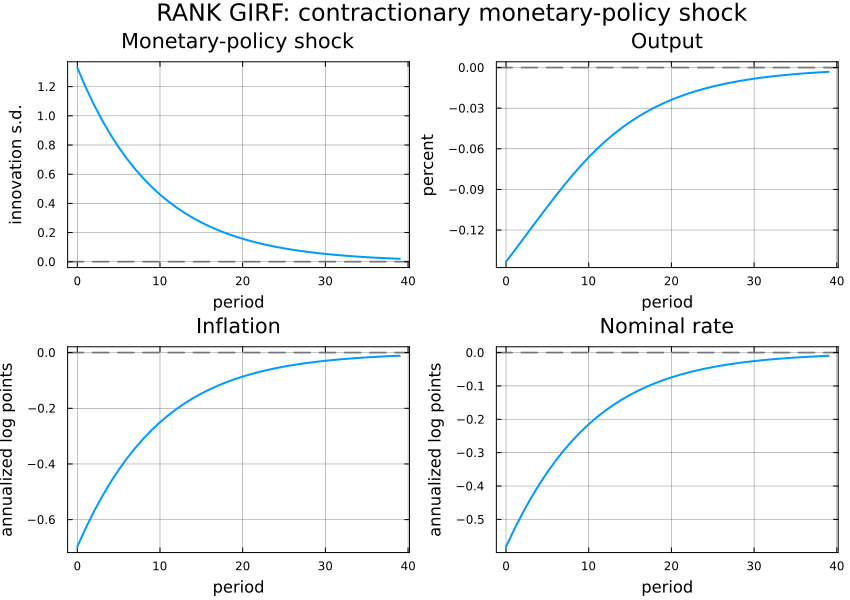

In [29]:
monetary_girf_plot = plot_rank_girf(
    monetary_girf;
    figure_title="RANK GIRF: contractionary monetary-policy shock",
)

## 12. Simulation moments

After convergence, simulation draws the finite aggregate Markov chain and looks up the corresponding equilibrium allocation. Because $s=(z,\eta)$ is discrete and persistent, the simulated series are step functions: flat segments mean that the Markov state has not changed, not that a numerical boundary has been reached. The figure shows the complete simulated sample.

Simulation moments
----------------------------------------------------
mean output                      0.949308
std log output                   0.061350
mean consumption                 0.942388
std log consumption              0.066444
mean gross inflation             1.004872
std log inflation                0.011224
simulated output range       (0.8304655267614807, 1.1505418503074896)
numerical output grid        (0.6, 1.4)


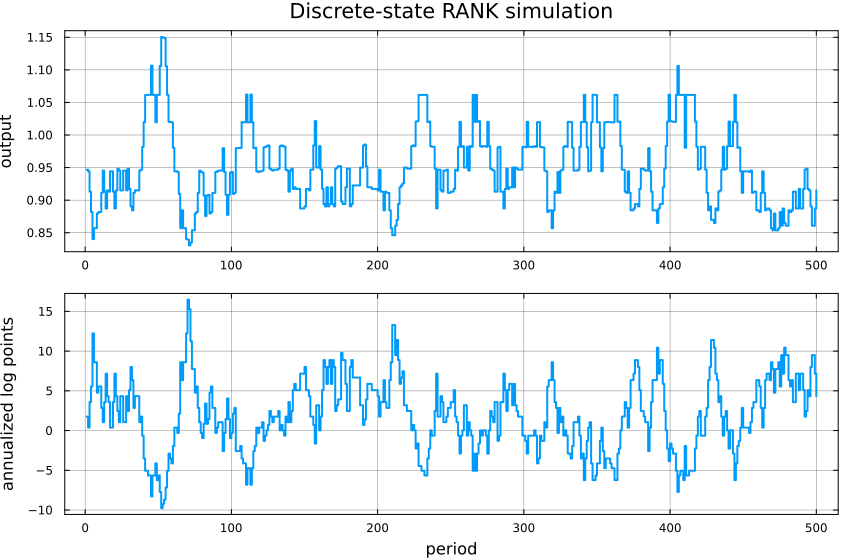

In [30]:
simulation = simulate_rank(result; length_path=par.simulation_length, seed=par.seed)

println("Simulation moments")
println(repeat("-", 52))
@printf("%-28s %12.6f\n", "mean output", mean(simulation.output))
@printf("%-28s %12.6f\n", "std log output", std(log.(simulation.output)))
@printf("%-28s %12.6f\n", "mean consumption", mean(simulation.consumption))
@printf("%-28s %12.6f\n", "std log consumption", std(log.(simulation.consumption)))
@printf("%-28s %12.6f\n", "mean gross inflation", mean(simulation.inflation))
@printf("%-28s %12.6f\n", "std log inflation", std(log.(simulation.inflation)))
println(rpad("simulated output range", 29), extrema(simulation.output))
println(rpad("numerical output grid", 29), extrema(model.output_grid))

plot_window = 1:par.simulation_length
p_output = plot(
    plot_window,
    simulation.output[plot_window];
    seriestype=:steppost,
    label=false,
    ylabel="output",
    title="Discrete-state RANK simulation",
)
p_inflation = plot(
    plot_window,
    400 .* log.(simulation.inflation[plot_window]);
    seriestype=:steppost,
    label=false,
    xlabel="period",
    ylabel="annualized log points",
)
simulation_plot = plot(p_output, p_inflation; layout=(2, 1), size=(850, 560))